# 📈 Evaluación del Modelo de Tasación Inmobiliaria (HistGradientBoosting)

Este notebook tiene como objetivo generar visualizaciones de evaluación del rendimiento del modelo predictivo de tasación inmobiliaria en su rama tabular (HistGradientBoostingRegressor).

Se generarán tres gráficas clave:
1. **Predicción vs. Realidad**: Scatter plot logarítmico para evaluar la bondad de ajuste (R²).
2. **Distribución de Residuos (Errores)**: Histograma para verificar la normalidad y sesgo del error predicho.
3. **Importancia de Variables (Feature Importance)**: Uso de Permutation Importance para interpretar qué características influyen más en el precio según el modelo maestro global.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Configuración de Alta Resolución para Memoria TFM ──
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})
sns.set_theme(style="whitegrid")

os.makedirs('graficas_exportadas', exist_ok=True)
print("✅ Entorno configurado.")


✅ Entorno configurado.


In [2]:
# ── Carga de Datos y Modelo ──
# 1. Cargar datos limpios
csv_path = '../data_pipeline/data/processed/propiedades_etiquetadas.csv'
df = pd.read_csv(csv_path)
df = df.dropna(subset=['barrio_limpio', 'precio_limpio', 'm2', 'estado_conservacion', 'calidad_materiales'])
df['precio_m2'] = df['precio_limpio'] / df['m2']

# 2. Recrear el Pipeline de Feature Engineering del train_tabular.py
with open('../app/barrios_encoding.json', 'r', encoding='utf-8') as f:
    barrios_encoding = json.load(f)
with open('../app/estado_encoding.json', 'r', encoding='utf-8') as f:
    estado_encoding = json.load(f)
with open('../app/calidad_encoding.json', 'r', encoding='utf-8') as f:
    calidad_encoding = json.load(f)

barrios_frecuentes = list(barrios_encoding.keys())
df['barrio_agrupado'] = df['barrio_limpio'].apply(lambda x: x if x in barrios_frecuentes else "Otros")

def apply_encoding(row, key):
    return barrios_encoding[row['barrio_agrupado']][key]

df['target_encoding_m2'] = df.apply(lambda r: apply_encoding(r, 'precio_m2_medio'), axis=1)
df['ratio_metros_zona'] = df['m2'] / df.apply(lambda r: apply_encoding(r, 'superficie_media'), axis=1)
df['ratio_hab_zona'] = df['habitaciones'] / df.apply(lambda r: apply_encoding(r, 'habs_media'), axis=1)
df['ratio_hab_zona'] = df['ratio_hab_zona'].fillna(1.0)

df['target_encoding_estado'] = df['estado_conservacion'].map(estado_encoding).fillna(1.0)
df['target_encoding_calidad'] = df['calidad_materiales'].map(calidad_encoding).fillna(1.0)
df['log_precio'] = np.log1p(df['precio_limpio'])

features = [
    'target_encoding_m2', 'm2', 'habitaciones', 'banos', 
    'tiene_ascensor', 'tiene_terraza', 'tiene_piscina', 'tiene_garaje', 'tiene_trastero',
    'ratio_metros_zona', 'ratio_hab_zona',
    'target_encoding_estado', 'target_encoding_calidad'
]

X = df[features]
y = df['log_precio']

# 3. División train/test (usar mismo random_state que el entrenamiento para validación)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Cargar modelo y predecir
model_bundle = joblib.load('../app/modelo_madrid_global.joblib')
modelo = model_bundle['modelo']
scaler = model_bundle['scaler']

X_test_scaled = scaler.transform(X_test)
y_pred_log = modelo.predict(X_test_scaled)

# Revertir logaritmo para el análisis de errores en euros reales
y_test_eur = np.expm1(y_test)
y_pred_eur = np.expm1(y_pred_log)

print("✅ Datos y modelo maestro cargados.")


✅ Datos y modelo maestro cargados.


### C.1 — Predicción vs Realidad (Bondad de Ajuste)

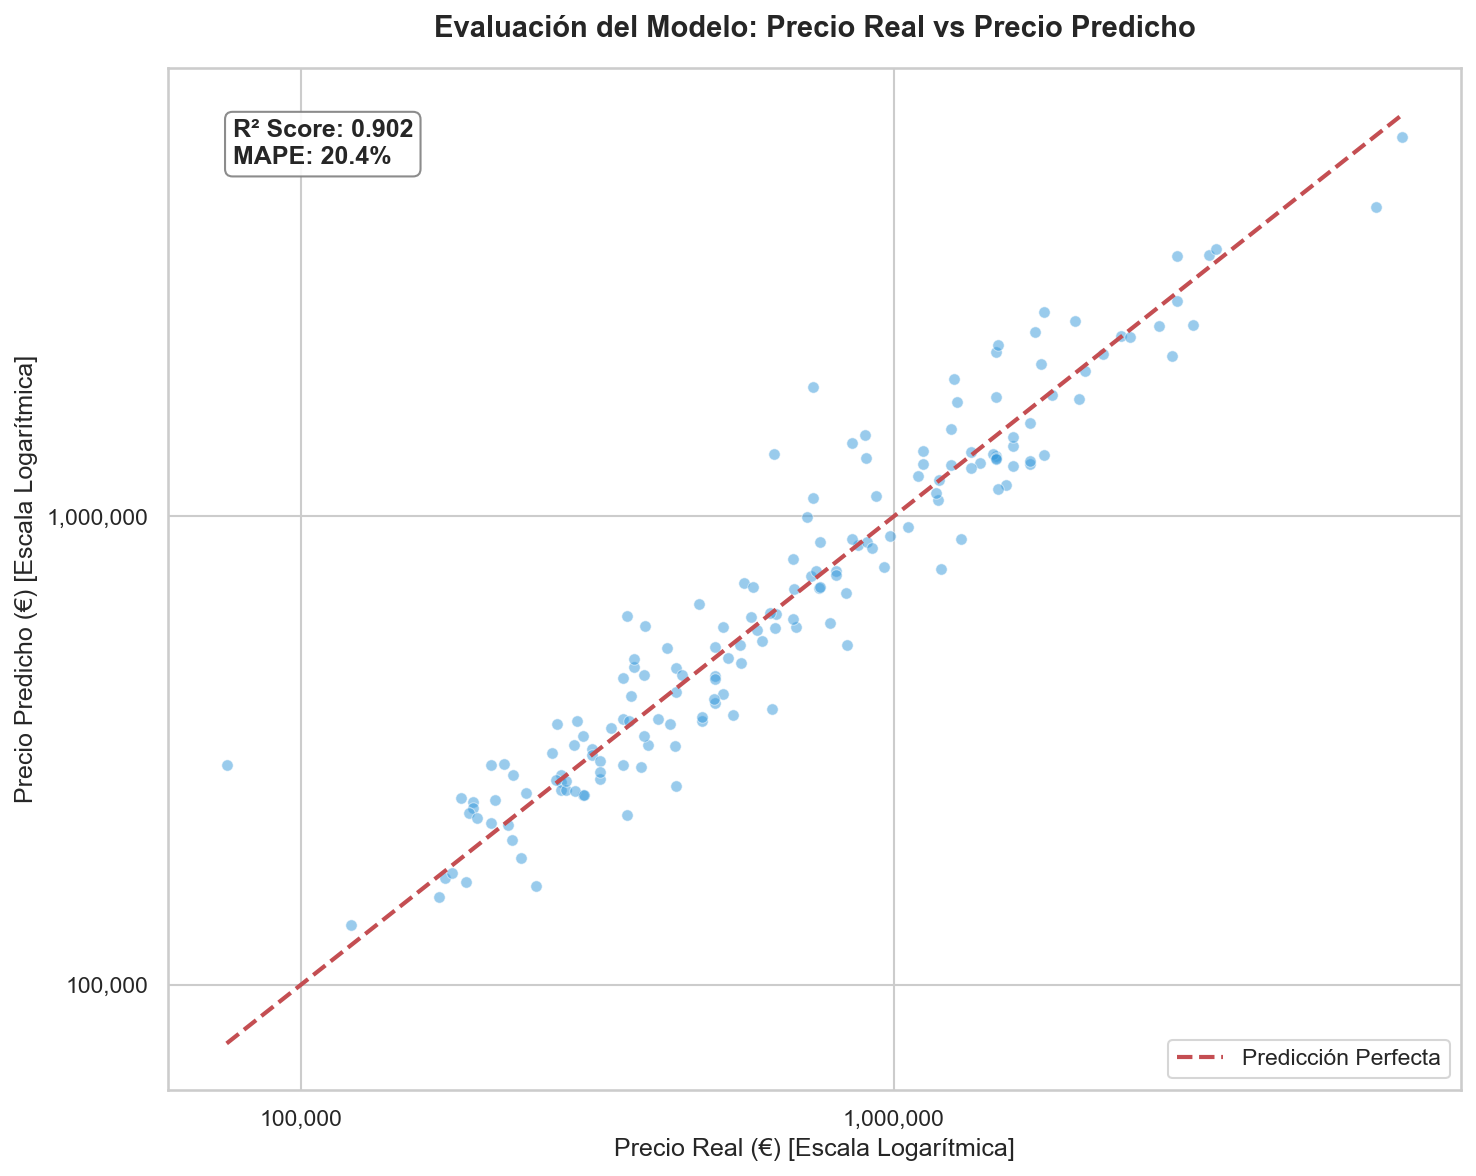

✅ Guardado: C1_Actual_vs_Predicho.png


In [3]:
# C.1 Gráfica de Actual vs Predicted
r2 = r2_score(y_test_eur, y_pred_eur)
mape = mean_absolute_percentage_error(y_test_eur, y_pred_eur) * 100

plt.figure(figsize=(10, 8))
plt.scatter(y_test_eur, y_pred_eur, alpha=0.5, color='#3498db', s=30, edgecolor='white', linewidth=0.5)

# Línea ideal
max_val = max(y_test_eur.max(), y_pred_eur.max())
min_val = min(y_test_eur.min(), y_pred_eur.min())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Predicción Perfecta')

# Configuración visual
plt.xscale('log')
plt.yscale('log')
plt.title('Evaluación del Modelo: Precio Real vs Precio Predicho', fontsize=14, weight='bold', pad=15)
plt.xlabel('Precio Real (€) [Escala Logarítmica]', fontsize=12)
plt.ylabel('Precio Predicho (€) [Escala Logarítmica]', fontsize=12)

# Formatear ejes logarítmicos
formatter = mticker.FuncFormatter(lambda y, _: f"{int(y):,}")
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)

# Métricas
bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9)
plt.text(0.05, 0.95, f'R² Score: {r2:.3f}\nMAPE: {mape:.1f}%', transform=plt.gca().transAxes, 
         fontsize=12, verticalalignment='top', bbox=bbox_props, weight='bold')

plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('graficas_exportadas/C1_Actual_vs_Predicho.png', bbox_inches='tight')
plt.show()
print("✅ Guardado: C1_Actual_vs_Predicho.png")


### C.2 — Distribución de los Residuos (Errores)

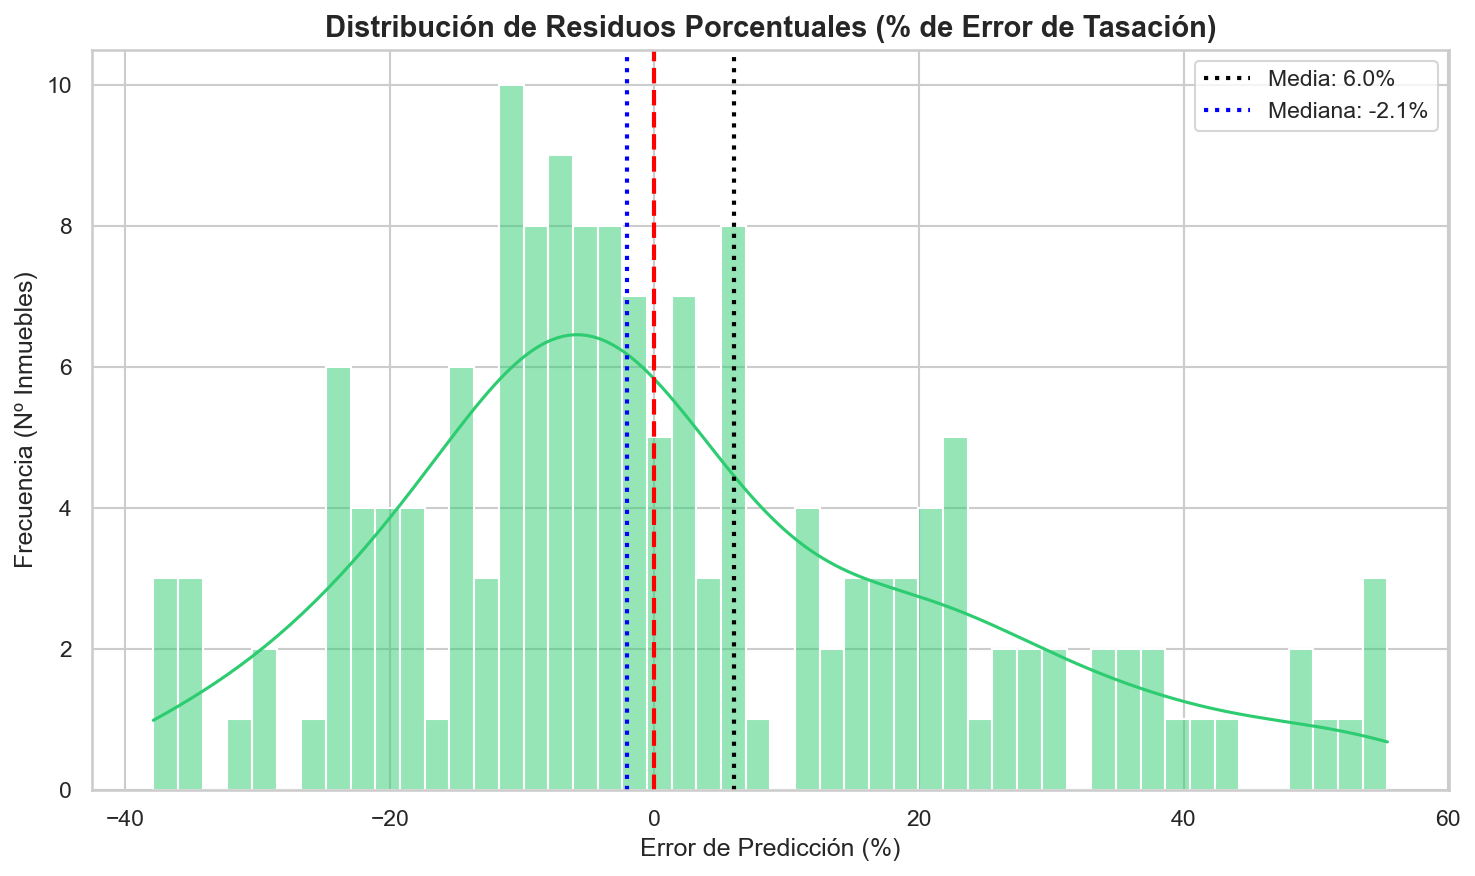

✅ Guardado: C2_Distribucion_Errores.png


In [4]:
# C.2 Histograma de residuos porcentuales
errores_pct = ((y_pred_eur - y_test_eur) / y_test_eur) * 100
# Filtrar outliers extremos para mejor visualización de la campana
errores_pct_viz = errores_pct[(errores_pct > -60) & (errores_pct < 60)]

plt.figure(figsize=(10, 6))
sns.histplot(errores_pct_viz, bins=50, kde=True, color='#2ecc71', edgecolor='white')

plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.axvline(errores_pct.mean(), color='black', linestyle=':', linewidth=2, label=f'Media: {errores_pct.mean():.1f}%')
plt.axvline(errores_pct.median(), color='blue', linestyle=':', linewidth=2, label=f'Mediana: {errores_pct.median():.1f}%')

plt.title('Distribución de Residuos Porcentuales (% de Error de Tasación)', fontsize=14, weight='bold')
plt.xlabel('Error de Predicción (%)', fontsize=12)
plt.ylabel('Frecuencia (Nº Inmuebles)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('graficas_exportadas/C2_Distribucion_Errores.png', bbox_inches='tight')
plt.show()
print("✅ Guardado: C2_Distribucion_Errores.png")


### C.3 — Importancia de las Variables (Feature Importance)

Calculando Permutation Importance (puede tardar unos segundos)...


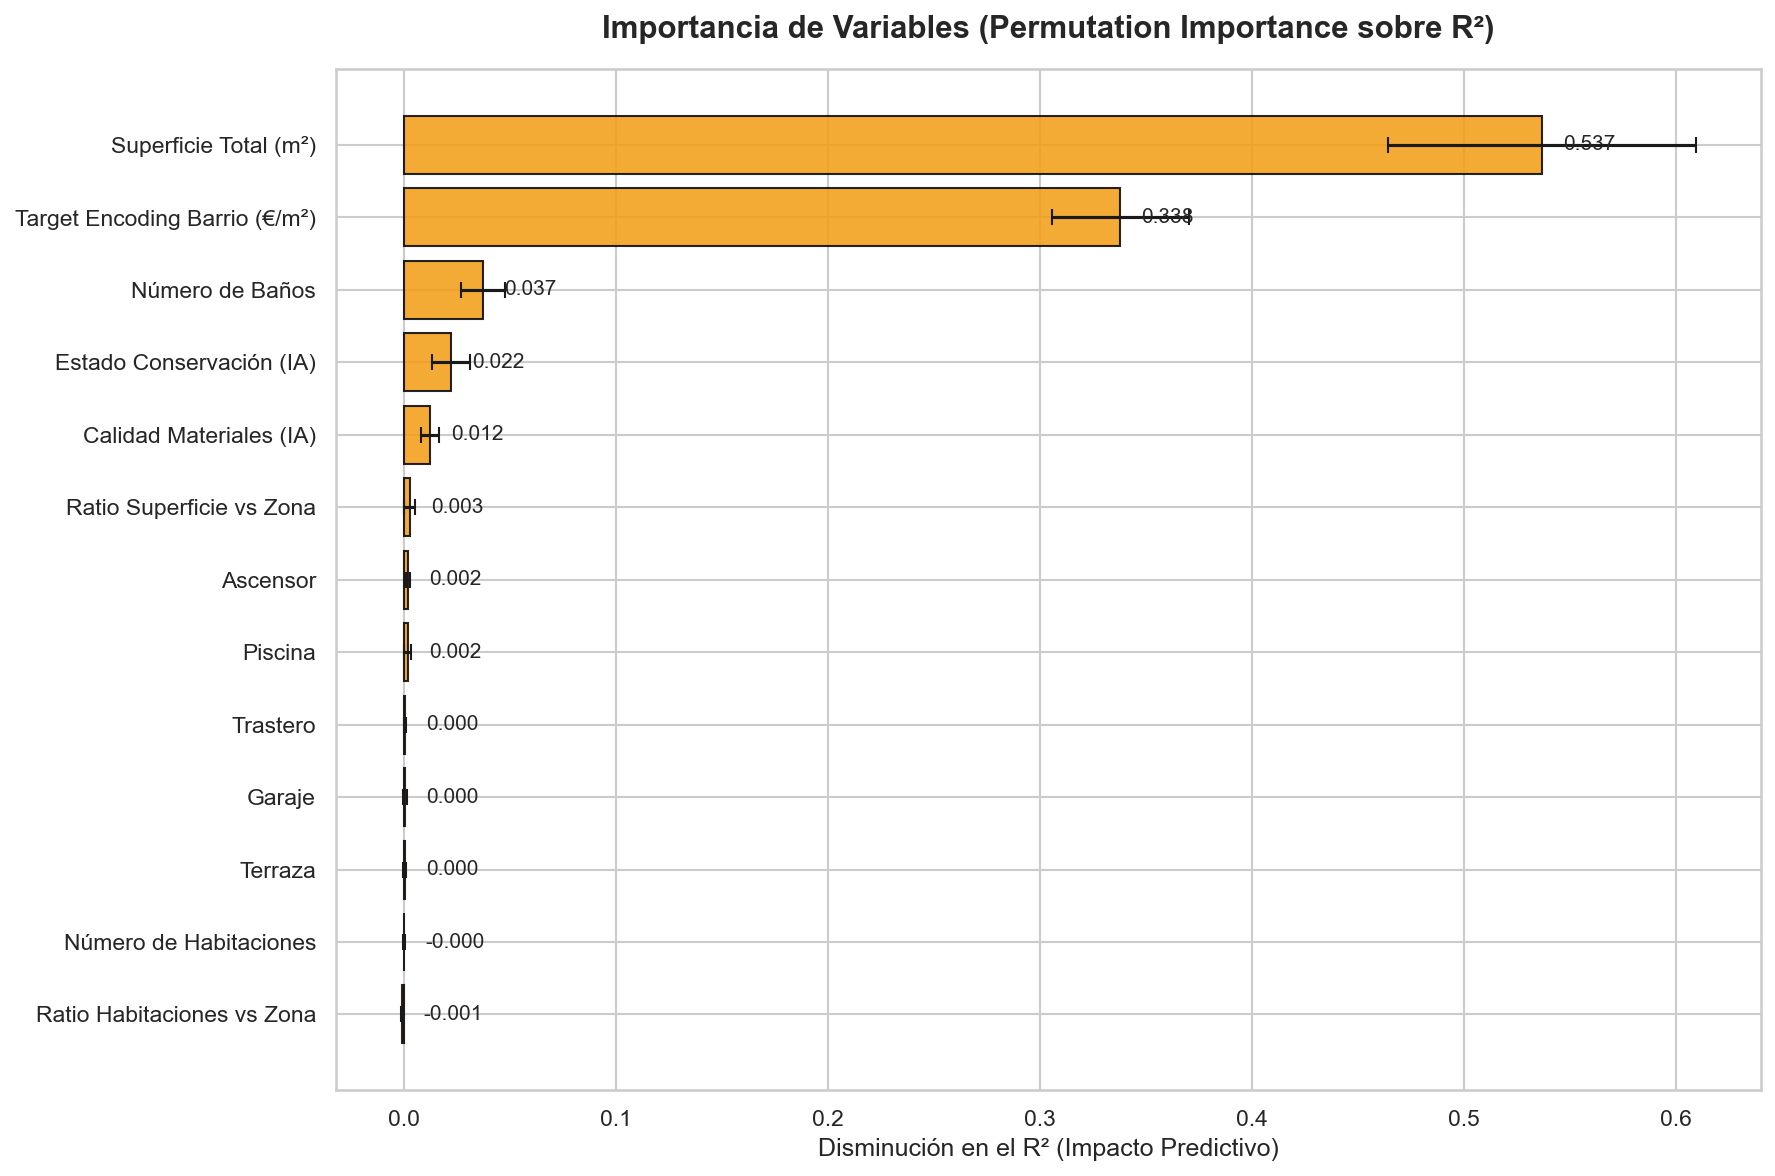

✅ Guardado: C3_Feature_Importance.png


In [5]:
# C.3 Permutation Feature Importance
# Calculamos la importancia usando el log del precio (que es como se entrenó)
print("Calculando Permutation Importance (puede tardar unos segundos)...")
results = permutation_importance(modelo, X_test_scaled, y_test, scoring='r2', n_repeats=10, random_state=42, n_jobs=-1)

# Nombres amigables para el gráfico
nombres_bonitos = {
    'target_encoding_m2': 'Target Encoding Barrio (€/m²)',
    'm2': 'Superficie Total (m²)',
    'habitaciones': 'Número de Habitaciones',
    'banos': 'Número de Baños',
    'tiene_ascensor': 'Ascensor',
    'tiene_terraza': 'Terraza',
    'tiene_piscina': 'Piscina',
    'tiene_garaje': 'Garaje',
    'tiene_trastero': 'Trastero',
    'ratio_metros_zona': 'Ratio Superficie vs Zona',
    'ratio_hab_zona': 'Ratio Habitaciones vs Zona',
    'target_encoding_estado': 'Estado Conservación (IA)',
    'target_encoding_calidad': 'Calidad Materiales (IA)'
}

importances_df = pd.DataFrame({
    'Variable': [nombres_bonitos.get(f, f) for f in features],
    'Importancia_Media': results.importances_mean,
    'Importancia_Std': results.importances_std
})

importances_df = importances_df.sort_values(by='Importancia_Media', ascending=True)

plt.figure(figsize=(12, 8))
bars = plt.barh(importances_df['Variable'], importances_df['Importancia_Media'], xerr=importances_df['Importancia_Std'], color='#f39c12', alpha=0.85, edgecolor='black', capsize=4)

plt.title('Importancia de Variables (Permutation Importance sobre R²)', fontsize=15, weight='bold', pad=15)
plt.xlabel('Disminución en el R² (Impacto Predictivo)', fontsize=12)

# Añadir valores numéricos
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('graficas_exportadas/C3_Feature_Importance.png', bbox_inches='tight')
plt.show()
print("✅ Guardado: C3_Feature_Importance.png")
